# ESC-50 Label-free CBM Evaluation (AST Backbone)

This notebook is focused on ESC-50 audio evaluation and visualization.

[x] load latest ESC-50 CBM checkpoint
[x] evaluate fold1_test accuracy
[x] explain per-audio predictions with concept bars
[x] generate Figure-3-style Sankey plots for selected class groups

In [1]:
import importlib
import json
import os
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

import cbm
import data_utils
import plots

from IPython.display import Audio, display

try:
    go = importlib.import_module("plotly.graph_objects")
    HAS_PLOTLY = True
except Exception as exc:
    HAS_PLOTLY = False
    go = None
    print(f"Plotly unavailable: {exc}")

In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

model_root = Path("saved_models")
auto_candidates = sorted(model_root.glob("esc50_cbm_*"))
if len(auto_candidates) == 0:
    raise FileNotFoundError("No ESC-50 CBM checkpoints found under saved_models/esc50_cbm_*")

# set this manually if you want a specific checkpoint
load_dir = str(auto_candidates[-1])

with open(os.path.join(load_dir, "args.txt"), "r", encoding="utf-8") as f:
    args = json.load(f)

if args.get("dataset") != "esc50":
    raise ValueError(f"Expected ESC-50 checkpoint, got dataset={args.get('dataset')}")

classes = data_utils.get_dataset_classes("esc50")
class_to_idx = {name: i for i, name in enumerate(classes)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

with open(os.path.join(load_dir, "concepts.txt"), "r", encoding="utf-8") as f:
    concepts = [line.strip() for line in f.readlines() if line.strip()]

model = cbm.load_cbm(load_dir, device).to(device).eval()

eval_split = args.get("test_split") or "fold1_test"
eval_dataset = data_utils.get_audio_dataset("esc50", eval_split)

print(f"Checkpoint: {load_dir}")
print(f"Device: {device}")
print(f"Eval split: {eval_split}")
print(f"Num eval clips: {len(eval_dataset)}")
print(f"Num concepts: {len(concepts)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: Adam-ousse/ast-esc50-finetuned-fold1
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint: saved_models/esc50_cbm_2026_04_15_11_36
Device: cuda
Eval split: fold1_test
Num eval clips: 400
Num concepts: 962


In [3]:
def evaluate_esc50_accuracy(model, dataset, device="cuda", batch_size=64):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=data_utils.collate_audio_batch,
    )
    total = 0
    correct = 0
    with torch.no_grad():
        for batch in loader:
            audio = batch["audio"].to(device)
            labels = batch["target"].to(device)
            logits, _ = model(audio)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.numel()
    return correct / max(total, 1)

acc = evaluate_esc50_accuracy(model, eval_dataset, device=device, batch_size=64)
print(f"ESC-50 {eval_split} accuracy: {acc * 100:.2f}%")

ESC-50 fold1_test accuracy: 94.00%


## Per-audio concept explanations
For each class in each group below, this section selects one clip, plays audio, and shows top concept contributions for the predicted class.


audio explanations for group: rooster, hen, crow, chirping birds
sample=201 | gt=rooster | pred=rooster | conf=0.977
path: data/esc50/raw/ESC-50-master/audio/1-40730-A-1.wav


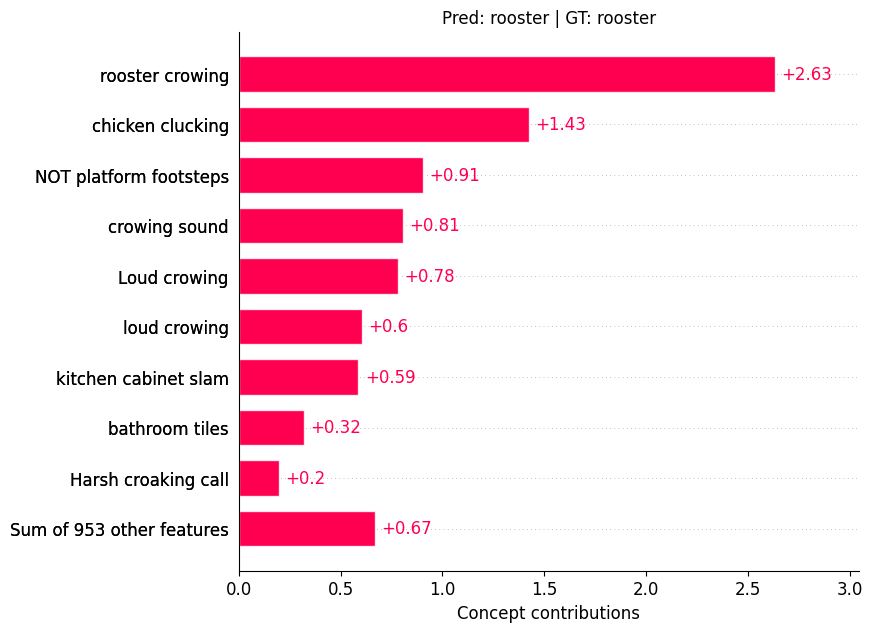

sample=163 | gt=hen | pred=hen | conf=0.952
path: data/esc50/raw/ESC-50-master/audio/1-31251-A-6.wav


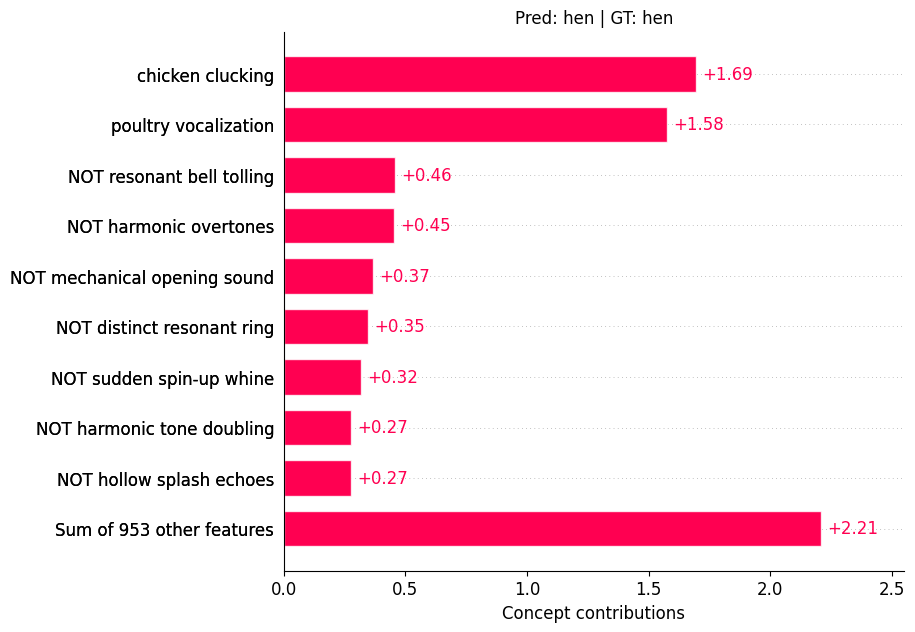

sample=390 | gt=crow | pred=crow | conf=0.979
path: data/esc50/raw/ESC-50-master/audio/1-96950-A-9.wav


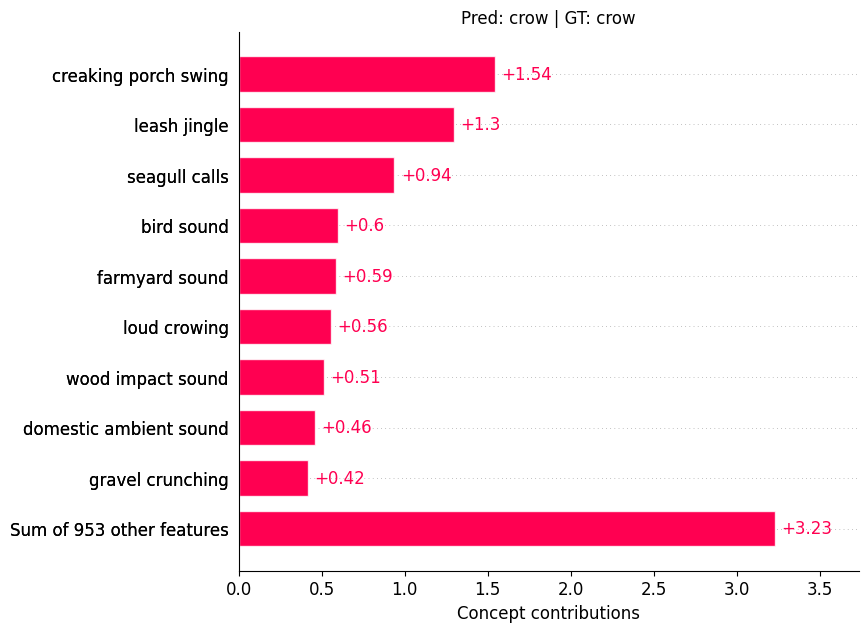

sample=1 | gt=chirping_birds | pred=chirping_birds | conf=0.734
path: data/esc50/raw/ESC-50-master/audio/1-100038-A-14.wav


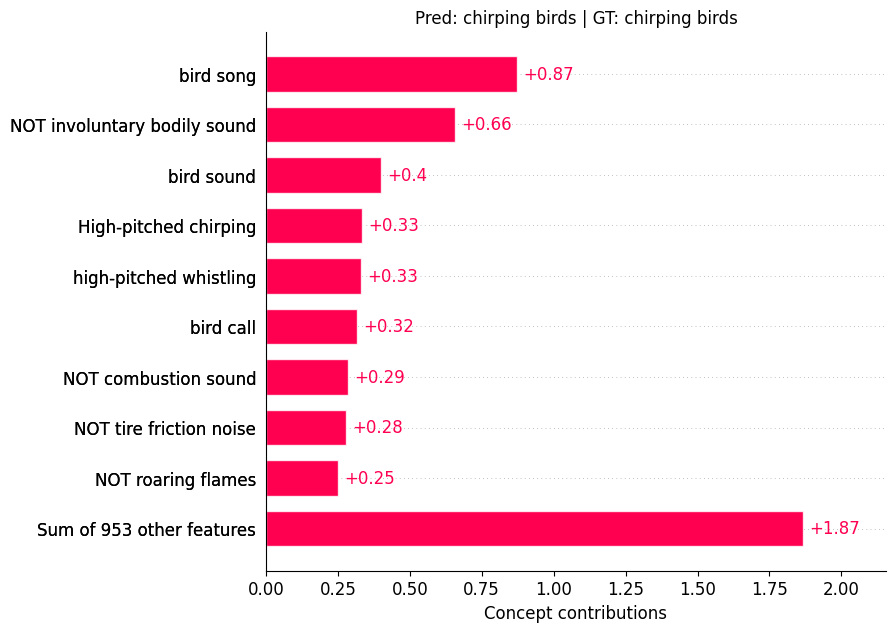


audio explanations for group: dog, cat, pig, cow, sheep
sample=14 | gt=dog | pred=dog | conf=0.979
path: data/esc50/raw/ESC-50-master/audio/1-110389-A-0.wav


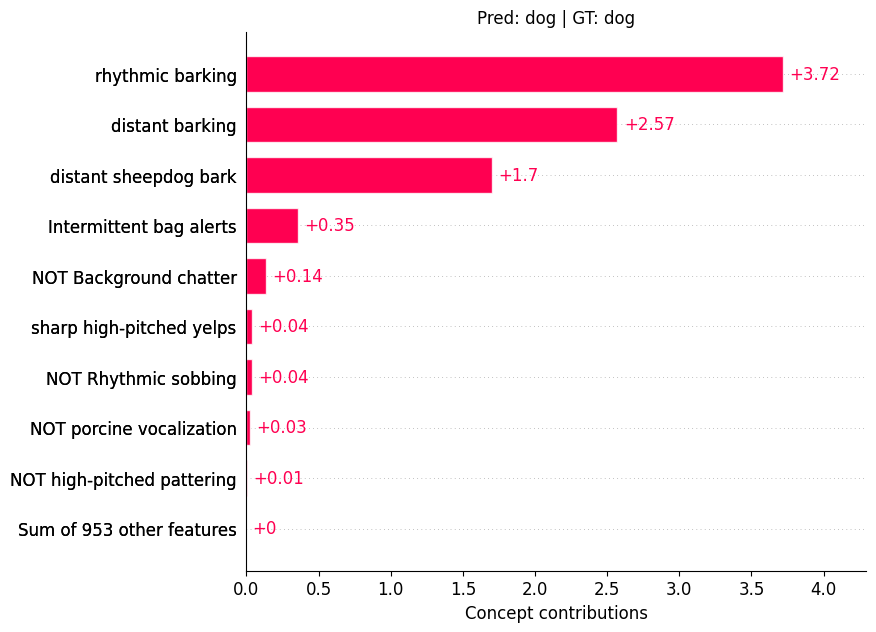

sample=176 | gt=cat | pred=cat | conf=0.968
path: data/esc50/raw/ESC-50-master/audio/1-34094-B-5.wav


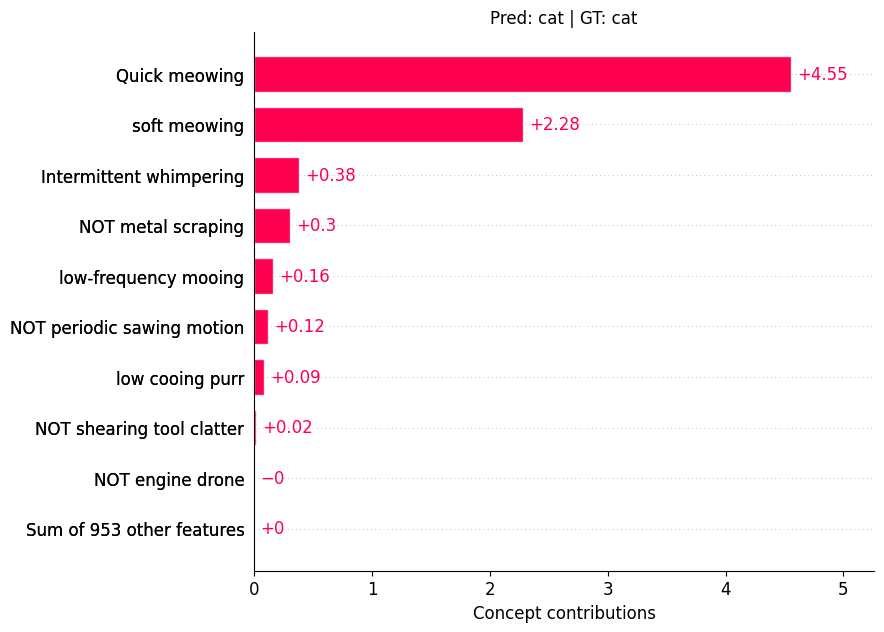

sample=133 | gt=pig | pred=pig | conf=0.986
path: data/esc50/raw/ESC-50-master/audio/1-260640-A-2.wav


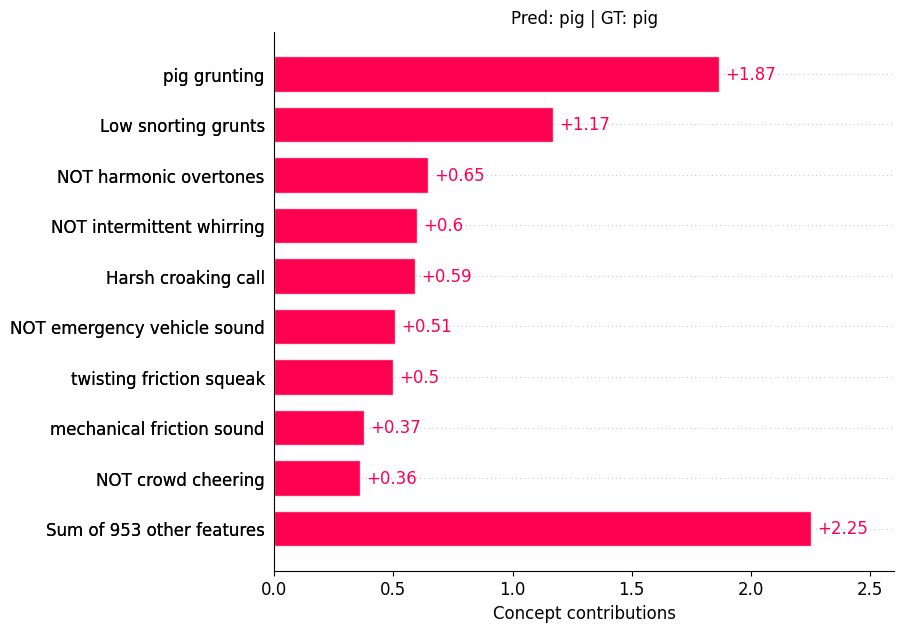

sample=49 | gt=cow | pred=cow | conf=0.973
path: data/esc50/raw/ESC-50-master/audio/1-16568-A-3.wav


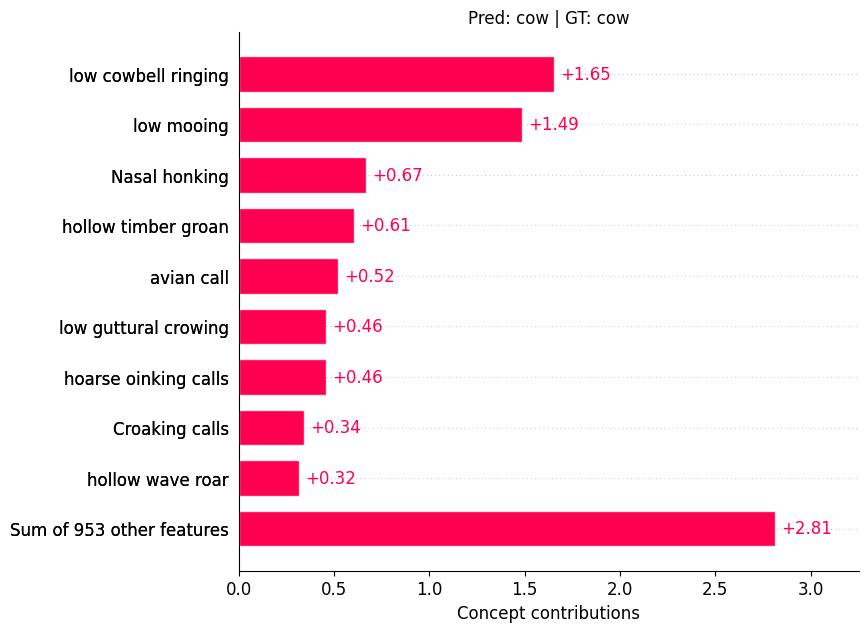

sample=236 | gt=sheep | pred=sheep | conf=0.980
path: data/esc50/raw/ESC-50-master/audio/1-49409-A-8.wav


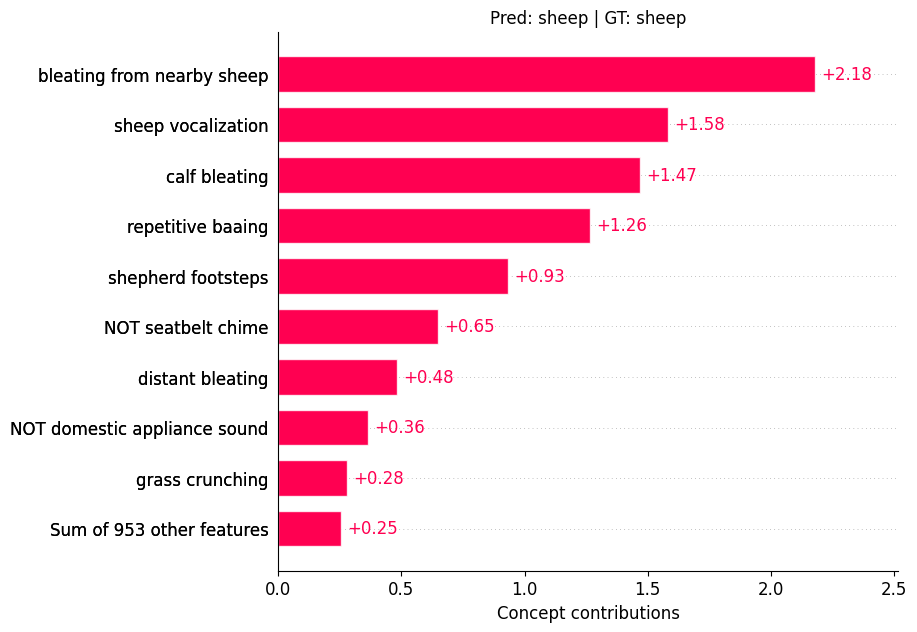


audio explanations for group: rain, sea waves, water drops, pouring water
sample=62 | gt=rain | pred=rain | conf=0.980
path: data/esc50/raw/ESC-50-master/audio/1-17367-A-10.wav


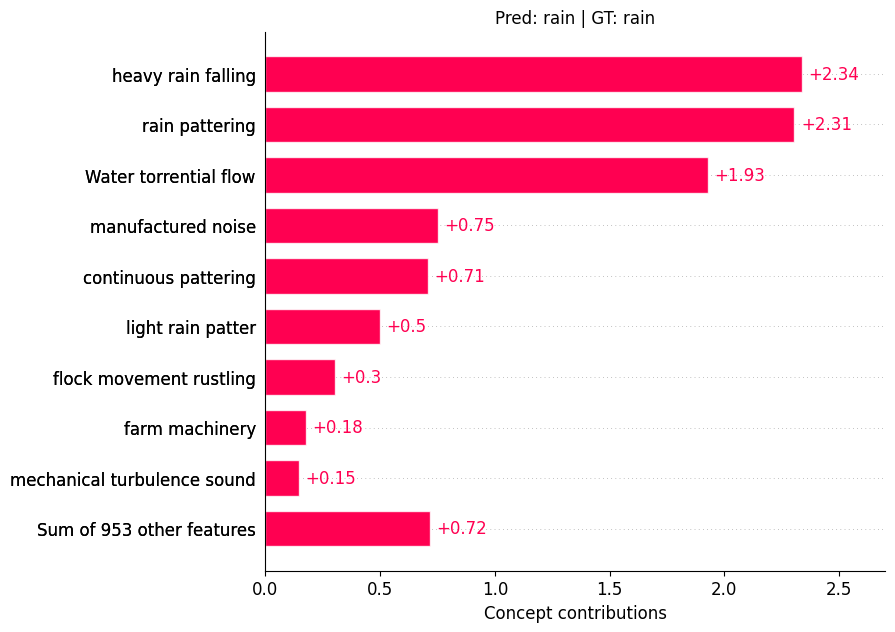

sample=149 | gt=sea_waves | pred=sea_waves | conf=0.897
path: data/esc50/raw/ESC-50-master/audio/1-28135-B-11.wav


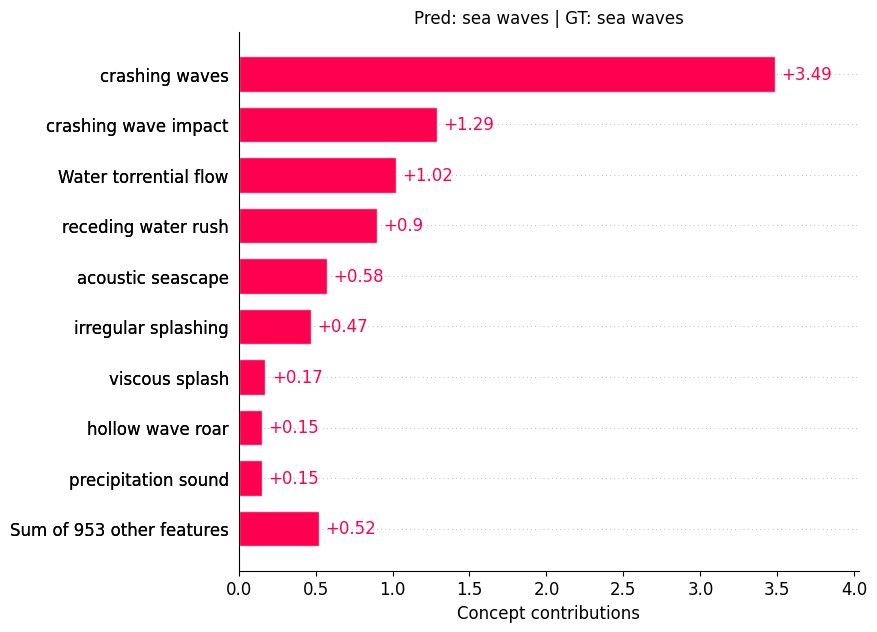

sample=241 | gt=water_drops | pred=water_drops | conf=0.995
path: data/esc50/raw/ESC-50-master/audio/1-50623-A-15.wav


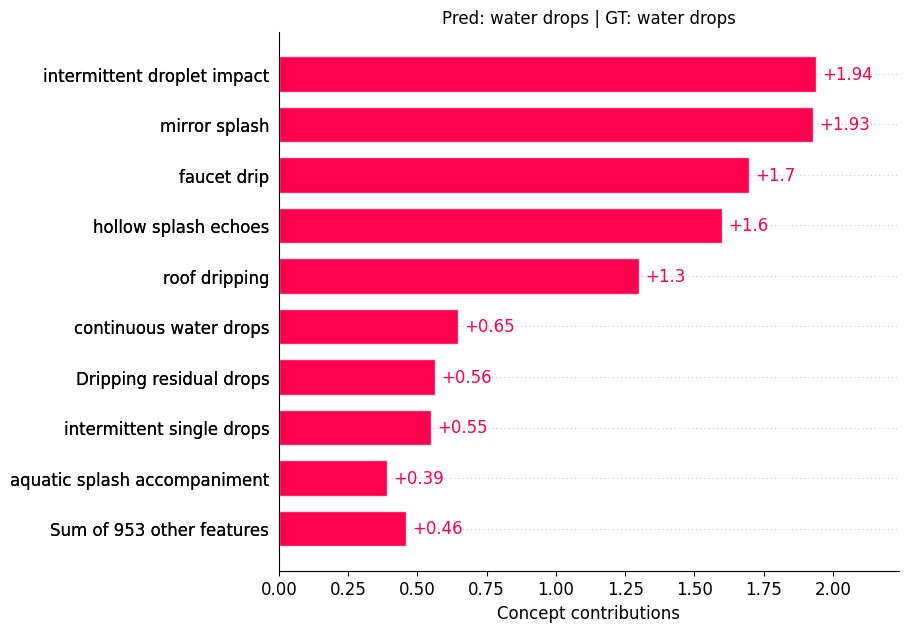

sample=319 | gt=pouring_water | pred=pouring_water | conf=0.974
path: data/esc50/raw/ESC-50-master/audio/1-67152-A-17.wav


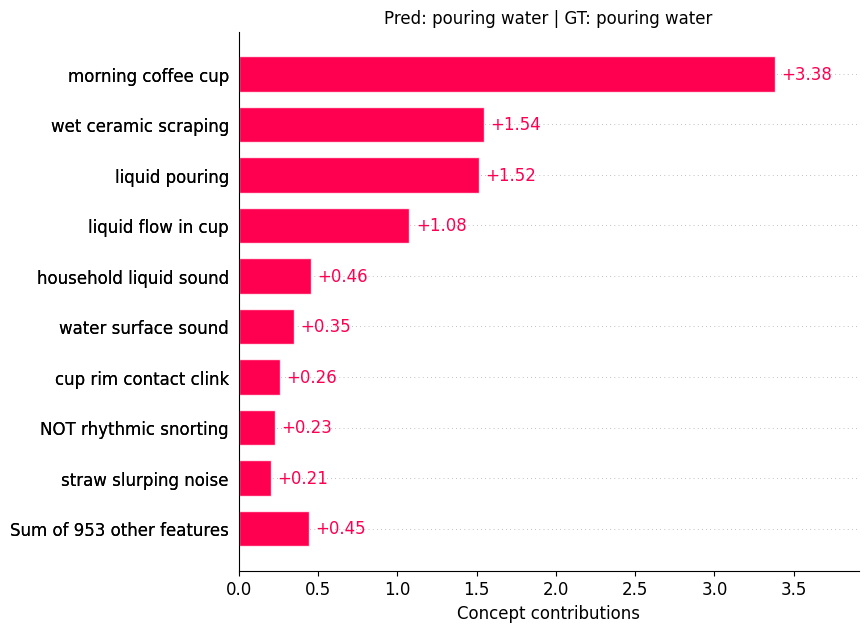


audio explanations for group: thunderstorm, fireworks
sample=5 | gt=thunderstorm | pred=thunderstorm | conf=0.974
path: data/esc50/raw/ESC-50-master/audio/1-101296-B-19.wav


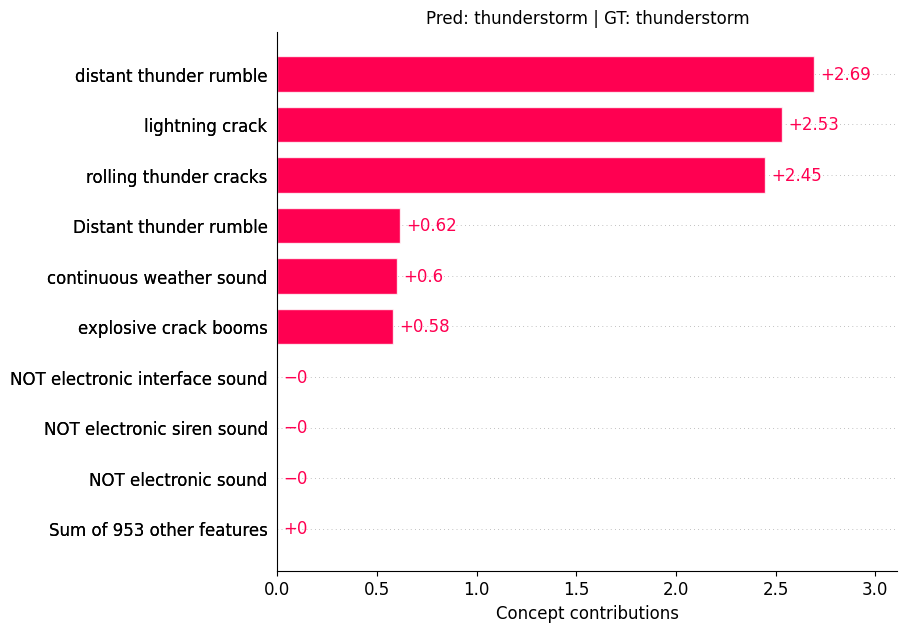

sample=20 | gt=fireworks | pred=fireworks | conf=0.760
path: data/esc50/raw/ESC-50-master/audio/1-115546-A-48.wav


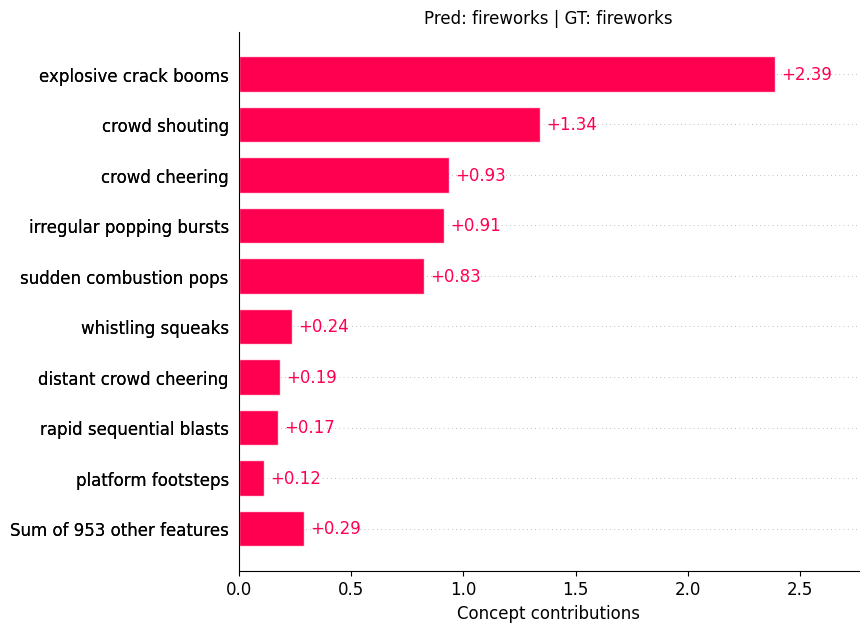


audio explanations for group: crying baby, sneezing, coughing, breathing, snoring
sample=104 | gt=crying_baby | pred=cat | conf=0.721
path: data/esc50/raw/ESC-50-master/audio/1-211527-A-20.wav


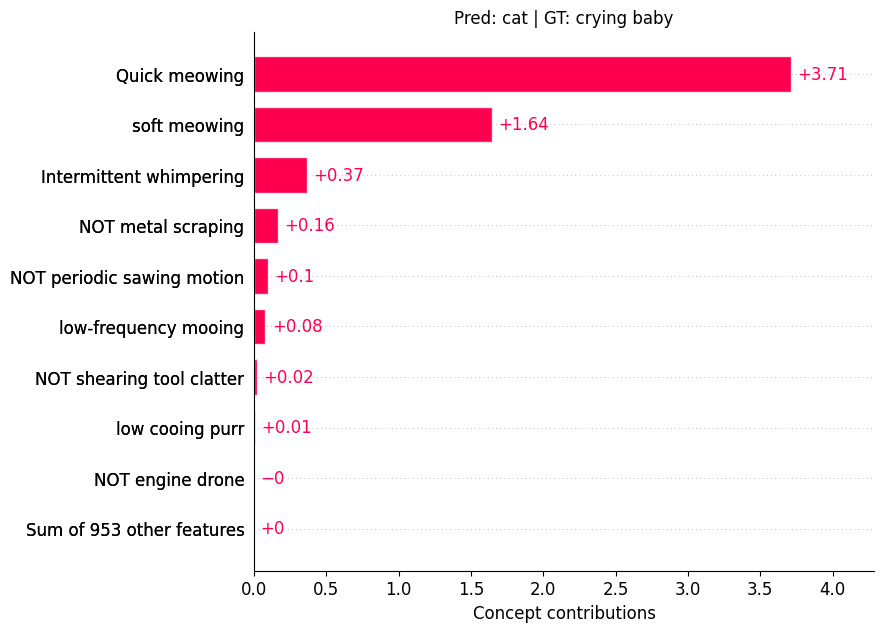

sample=295 | gt=sneezing | pred=sneezing | conf=0.951
path: data/esc50/raw/ESC-50-master/audio/1-59324-A-21.wav


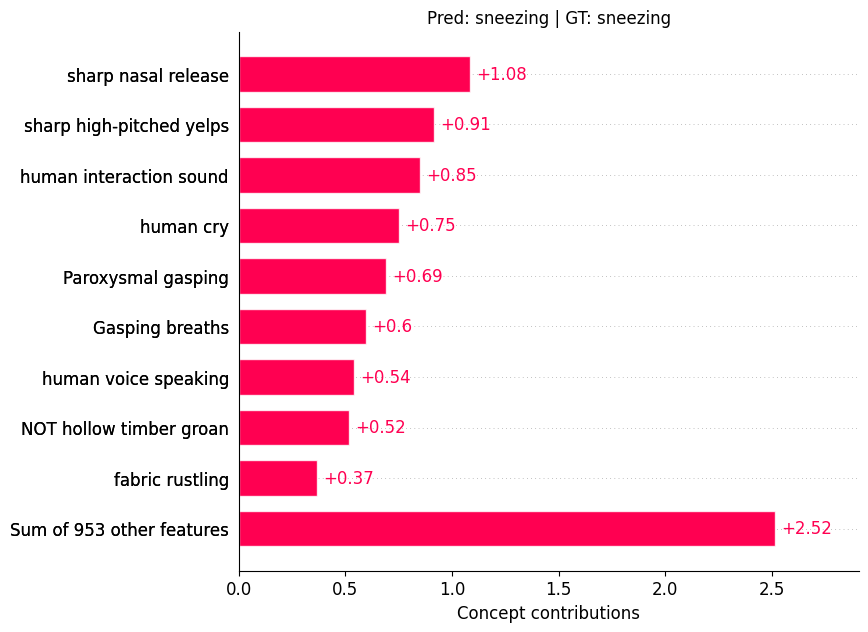

sample=84 | gt=coughing | pred=coughing | conf=0.968
path: data/esc50/raw/ESC-50-master/audio/1-19111-A-24.wav


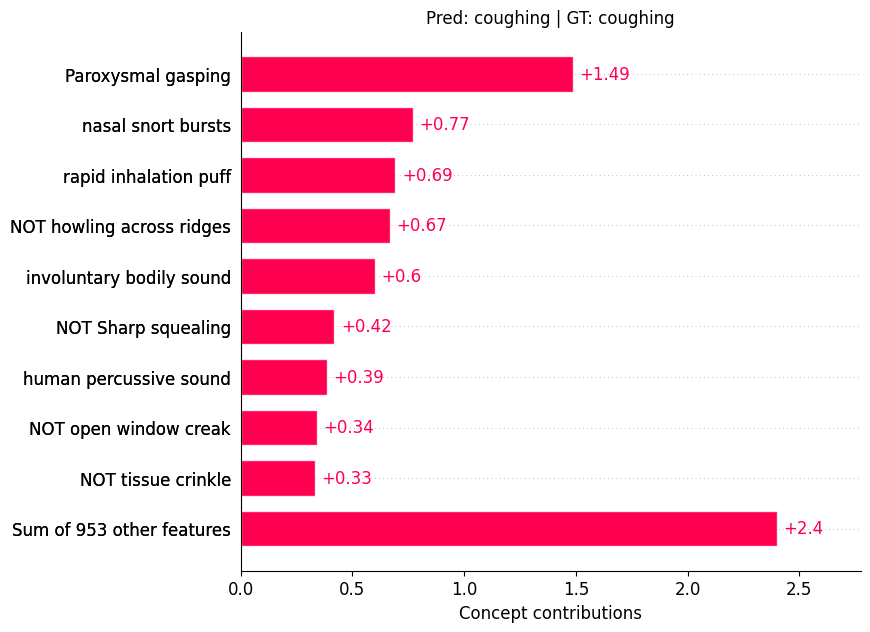

sample=159 | gt=breathing | pred=breathing | conf=0.990
path: data/esc50/raw/ESC-50-master/audio/1-30709-A-23.wav


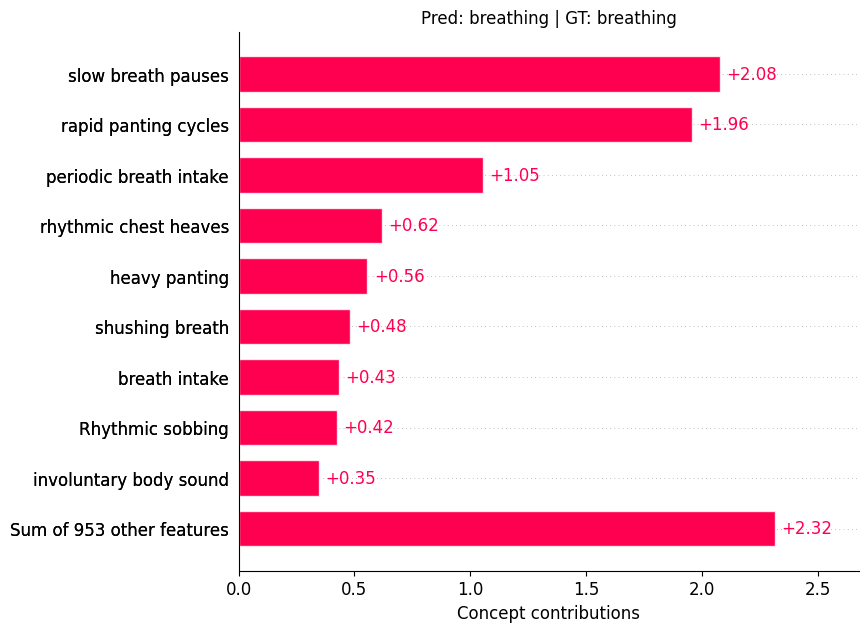

sample=198 | gt=snoring | pred=snoring | conf=0.922
path: data/esc50/raw/ESC-50-master/audio/1-39937-A-28.wav


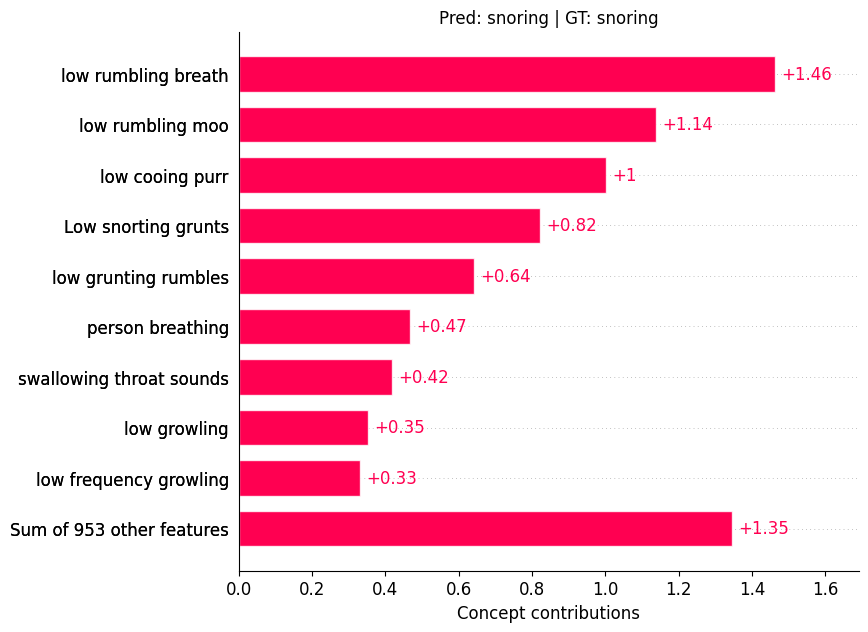


audio explanations for group: door wood knock, door wood creaks, can opening, glass breaking
sample=6 | gt=door_wood_knock | pred=door_wood_knock | conf=0.984
path: data/esc50/raw/ESC-50-master/audio/1-101336-A-30.wav


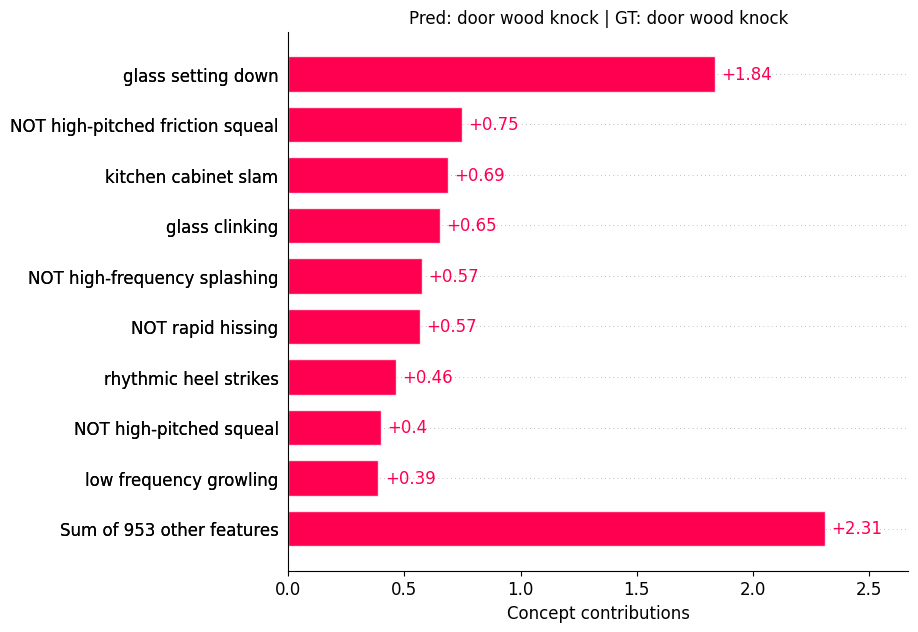

sample=258 | gt=door_wood_creaks | pred=door_wood_creaks | conf=0.998
path: data/esc50/raw/ESC-50-master/audio/1-51805-G-33.wav


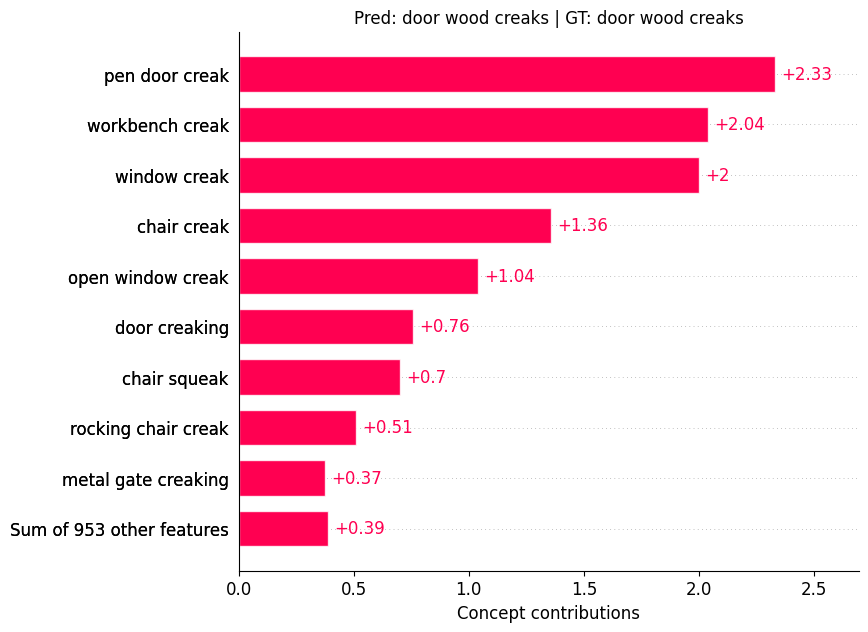

sample=7 | gt=can_opening | pred=can_opening | conf=0.968
path: data/esc50/raw/ESC-50-master/audio/1-101404-A-34.wav


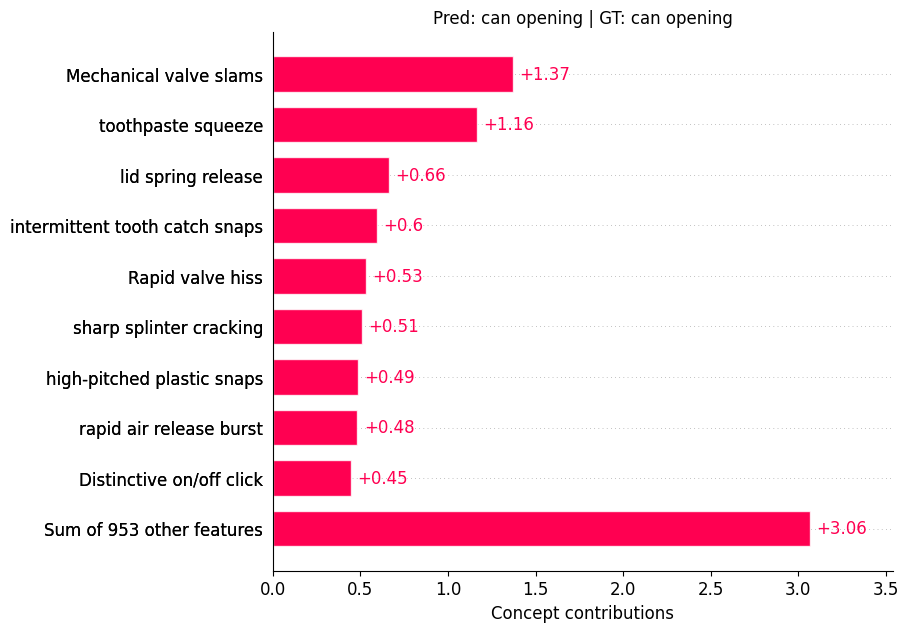

sample=371 | gt=glass_breaking | pred=glass_breaking | conf=0.888
path: data/esc50/raw/ESC-50-master/audio/1-84705-A-39.wav


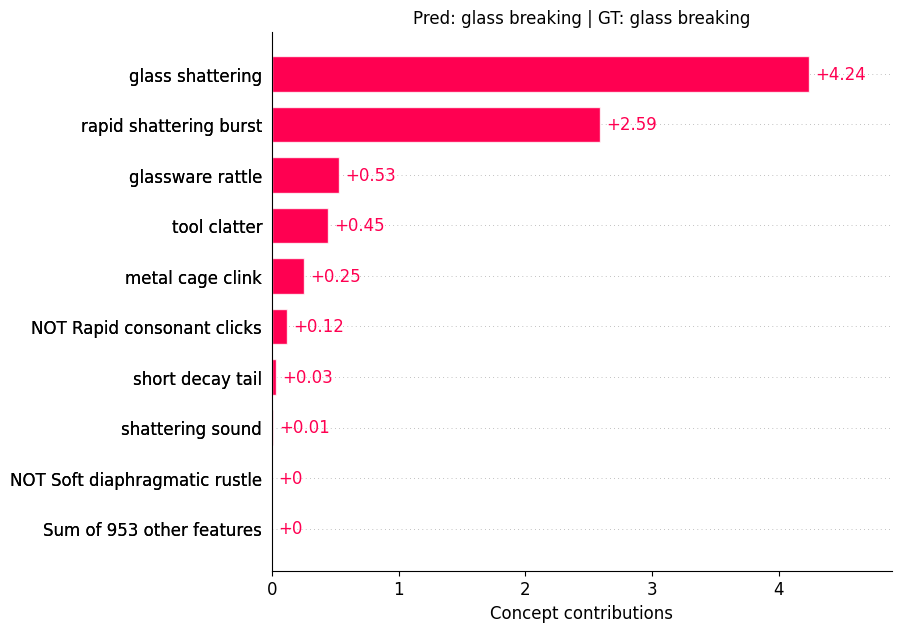


audio explanations for group: mouse click, keyboard typing
sample=26 | gt=mouse_click | pred=mouse_click | conf=0.636
path: data/esc50/raw/ESC-50-master/audio/1-118206-A-31.wav


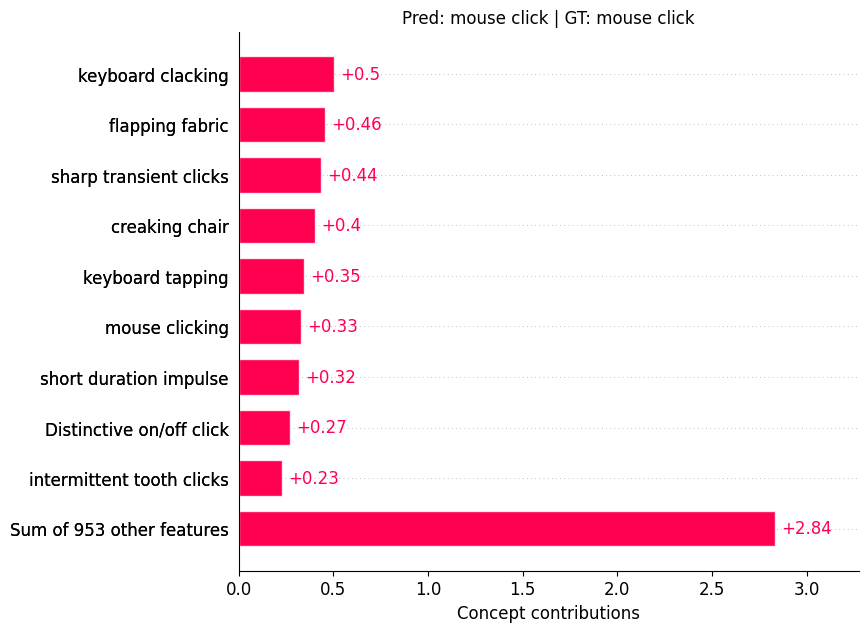

sample=302 | gt=keyboard_typing | pred=keyboard_typing | conf=0.995
path: data/esc50/raw/ESC-50-master/audio/1-61212-A-32.wav


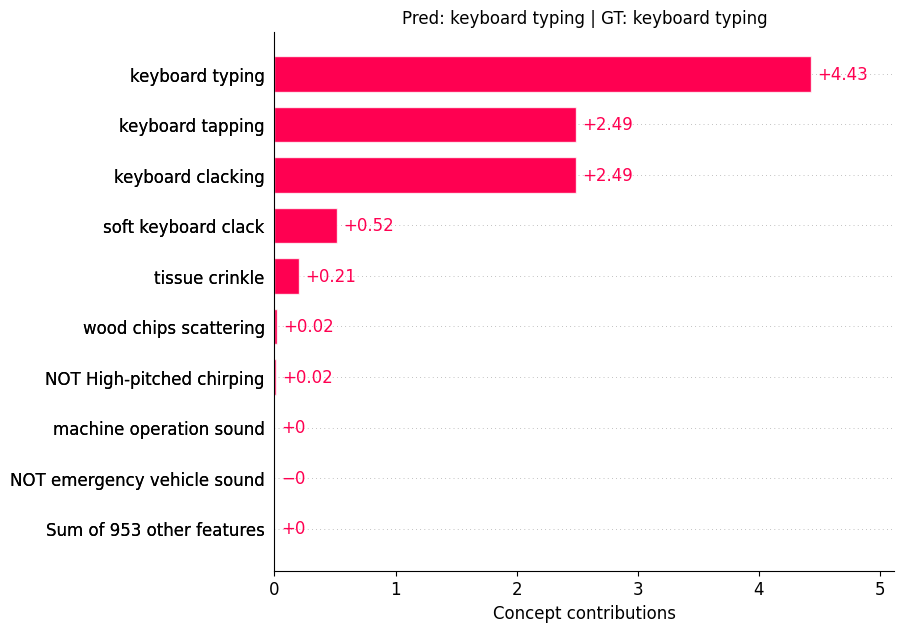


audio explanations for group: engine, train, airplane, helicopter
sample=240 | gt=engine | pred=engine | conf=0.987
path: data/esc50/raw/ESC-50-master/audio/1-50455-A-44.wav


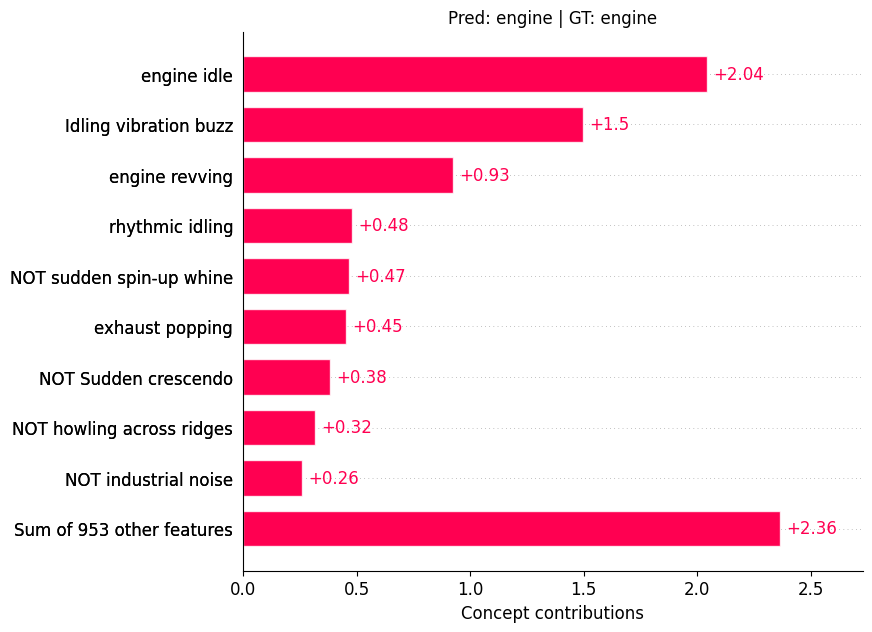

sample=378 | gt=train | pred=train | conf=0.974
path: data/esc50/raw/ESC-50-master/audio/1-88409-A-45.wav


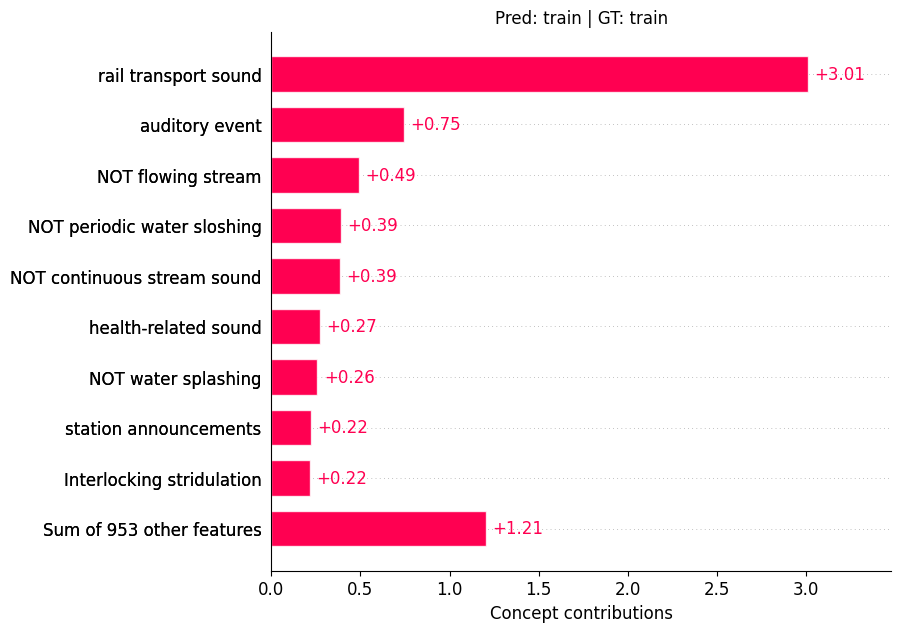

sample=189 | gt=airplane | pred=helicopter | conf=0.456
path: data/esc50/raw/ESC-50-master/audio/1-36929-A-47.wav


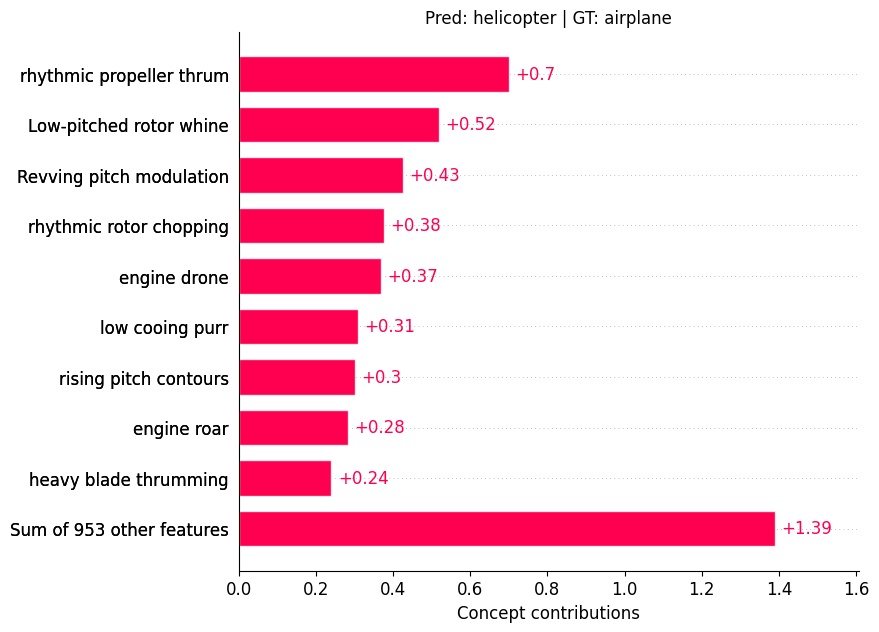

sample=56 | gt=helicopter | pred=vacuum_cleaner | conf=0.285
path: data/esc50/raw/ESC-50-master/audio/1-172649-B-40.wav


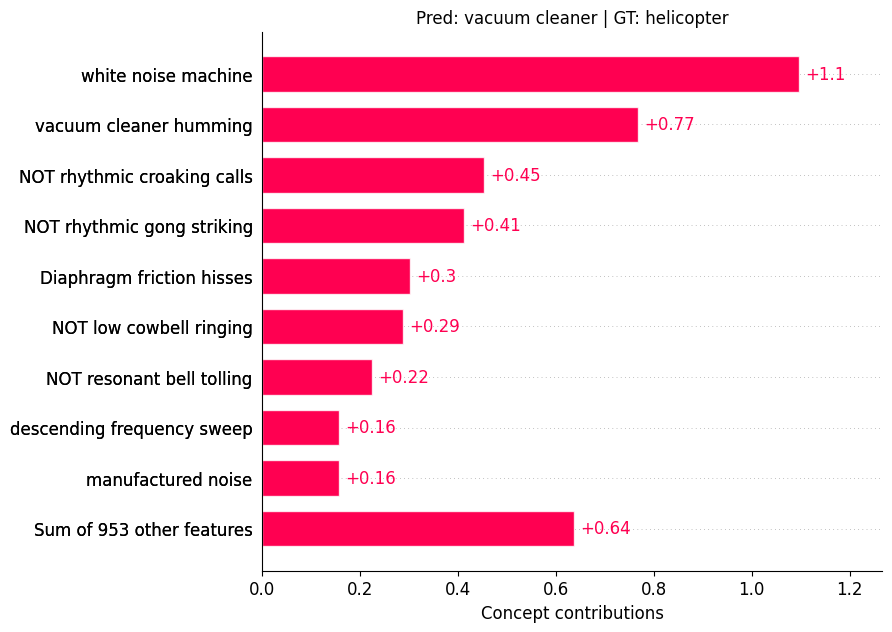

In [4]:
def _pretty(name):
    return name.replace("_", " ")

def build_class_index(dataset):
    out = {}
    for i, sample in enumerate(dataset.samples):
        cls_idx = int(sample["label_idx"])
        out.setdefault(cls_idx, []).append(i)
    return out

indices_by_class_idx = build_class_index(eval_dataset)

def show_audio_explanation(sample_idx, max_concepts=10):
    sample = eval_dataset[sample_idx]
    audio = sample["audio"]
    sr = int(sample["sr"])
    gt_idx = int(sample["target"])

    with torch.no_grad():
        logits, concept_act = model(audio.unsqueeze(0).to(device))

    logits = logits[0].detach().cpu()
    concept_act = concept_act[0].detach().cpu()
    probs = torch.softmax(logits, dim=0)
    pred_idx = int(torch.argmax(probs).item())

    print(f"sample={sample_idx} | gt={idx_to_class[gt_idx]} | pred={idx_to_class[pred_idx]} | conf={probs[pred_idx]:.3f}")
    print(f"path: {sample['path']}")
    display(Audio(audio.squeeze(0).cpu().numpy(), rate=sr))

    contrib = (concept_act * model.final.weight[pred_idx].detach().cpu()).numpy()
    feature_names = [(("NOT " if concept_act[i] < 0 else "") + concepts[i]) for i in range(len(concepts))]
    title = f"Pred: {_pretty(idx_to_class[pred_idx])} | GT: {_pretty(idx_to_class[gt_idx])}"
    plots.bar(contrib.copy(), feature_names, max_display=max_concepts, title=title, fontsize=12)

CLASS_GROUPS = [
    ["rooster", "hen", "crow", "chirping_birds"],
    ["dog", "cat", "pig", "cow", "sheep"],
    ["rain", "sea_waves", "water_drops", "pouring_water"],
    ["thunderstorm", "fireworks"],
    ["crying_baby", "sneezing", "coughing", "breathing", "snoring"],
    ["door_wood_knock", "door_wood_creaks", "can_opening", "glass_breaking"],
    ["mouse_click", "keyboard_typing"],
    ["engine", "train", "airplane", "helicopter"],
]

for group in CLASS_GROUPS:
    missing = [c for c in group if c not in class_to_idx]
    if missing:
        raise ValueError(f"Missing classes in ESC-50 labels: {missing}")

rng = random.Random(7)
for group in CLASS_GROUPS:
    print("\n" + "=" * 100)
    print("audio explanations for group:", ", ".join([_pretty(c) for c in group]))
    print("=" * 100)
    for class_name in group:
        cls_idx = class_to_idx[class_name]
        pool = indices_by_class_idx.get(cls_idx, [])
        if len(pool) == 0:
            print(f"No samples found for class {class_name}")
            continue
        sample_idx = rng.choice(pool)
        show_audio_explanation(sample_idx=sample_idx, max_concepts=10)

## Figure 3-style final-layer weight visualizations
Each figure shows concept-to-class links for one selected class group, using signed final-layer weights from the trained ESC-50 CBM.

In [7]:
def make_group_sankey(group_classes, top_k=5, min_abs_weight=0.03):
    if not HAS_PLOTLY:
        raise ImportError("Plotly is required for Sankey rendering. Install with: pip install plotly")

    class_ids = [class_to_idx[c] for c in group_classes]
    final_w = model.final.weight.detach().cpu().numpy()

    links = []
    for class_name, cls_id in zip(group_classes, class_ids):
        w = final_w[cls_id]
        ranked = np.argsort(np.abs(w))[::-1]
        selected = [i for i in ranked if abs(w[i]) >= min_abs_weight][:top_k]
        if len(selected) == 0:
            selected = ranked[:top_k]
        for concept_idx in selected:
            links.append((concept_idx, class_name, float(w[concept_idx])))

    unique_concepts = sorted({cidx for cidx, _, _ in links})
    concept_node = {cidx: i for i, cidx in enumerate(unique_concepts)}
    class_node = {name: len(unique_concepts) + i for i, name in enumerate(group_classes)}

    node_labels = [concepts[cidx] for cidx in unique_concepts] + [_pretty(name) for name in group_classes]
    node_colors = ["rgba(120,120,120,0.6)" for _ in unique_concepts] + [
        "rgba(217,95,2,0.8)",
        "rgba(27,158,119,0.8)",
        "rgba(117,112,179,0.8)",
        "rgba(231,41,138,0.8)",
        "rgba(102,166,30,0.8)",
    ][:len(group_classes)]

    sources = []
    targets = []
    values = []
    colors = []
    hover = []

    for cidx, cname, weight in links:
        sources.append(concept_node[cidx])
        targets.append(class_node[cname])
        values.append(abs(weight))
        colors.append("rgba(214,39,40,0.45)" if weight >= 0 else "rgba(31,119,180,0.45)")
        hover.append(f"{concepts[cidx]} -> {_pretty(cname)}<br>weight={weight:+.4f}")

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=16,
                    thickness=14,
                    line=dict(color="rgba(40,40,40,0.25)", width=0.5),
                    label=node_labels,
                    color=node_colors,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color=colors,
                    customdata=hover,
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ]
    )
    fig.update_layout(
        title=f"ESC-50 CBM | Figure 3 style | {' vs '.join([_pretty(c) for c in group_classes])}",
        width=1300,
        height=max(520, 140 * len(group_classes)),
        font=dict(size=13),
    )
    fig.show()

for group in CLASS_GROUPS:
    make_group_sankey(group_classes=group, top_k=4, min_abs_weight=0.03)